# Week 3 — Who matters, and why

Centrality on the Marvel network, and the question week 2 taught us to keep
asking: *compared to what?*

This notebook produces every figure and number in
[the week 3 post](../weeks/week3/week3.html).

**The claim we chase:** Spider-Man tops every centrality here, and that is not a
finding — it is what 106 links buys you in *any* network with these degrees. The
characters worth naming are the ones whose position beats their degree. The
biggest of them has two links.

In [1]:
import sys
sys.path.append("../src")

from collections import deque
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

import marvel
marvel.use_site_style()

GREY = "#7C89A8"
N_SHUFFLES = 200

G  = marvel.load_graph()            # directed, 303 nodes
GC = marvel.giant_component(G)      # undirected, 277
name = marvel.names(G)
short = lambda v: (name[v].replace(" (character)", "").replace(" (Marvel Comics)", "")
                   .replace(" (Natasha Romanova)", "").replace(" (comics)", ""))
n, m = GC.number_of_nodes(), GC.number_of_edges()
print(f"n = {n}   m = {m}")

n = 277   m = 1421


## 1. Distances, and our own BFS

Everything path-based here comes out of breadth-first search. Exercise 3.3 asks
us to write it rather than call it, and then check it — which is the habit the
whole course is about, so the validation cell stays in.

In [2]:
def bfs(G, source):
    """Distances from `source` to every reachable node. Rings, not recursion."""
    dist = {source: 0}
    queue = deque([source])
    while queue:
        v = queue.popleft()
        for w in G[v]:
            if w not in dist:
                dist[w] = dist[v] + 1
                queue.append(w)
    return dist

rng = np.random.default_rng(3)
starts = rng.choice(list(GC), 20, replace=False)
agree = all(bfs(GC, s) == nx.single_source_shortest_path_length(GC, s) for s in starts)
print("our BFS matches networkx on 20 random starts:", agree)
assert agree

our BFS matches networkx on 20 random starts: True


In [3]:
ecc = nx.eccentricity(GC)
print(f"average distance {nx.average_shortest_path_length(GC):.4f}")
print(f"diameter {max(ecc.values())}   radius {min(ecc.values())}")
print("center:", [short(v) for v in nx.center(GC)])

pairs = {}
for s, dd in nx.all_pairs_shortest_path_length(GC):
    for t, d in dd.items():
        if s < t:
            pairs[d] = pairs.get(d, 0) + 1
total = sum(pairs.values())
for d in sorted(pairs):
    print(f"   d={d}  {pairs[d]:6d}  {pairs[d]/total:.4f}")
print(f"share at 2 or 3: {(pairs[2]+pairs[3])/total:.3f}")

average distance 2.6743
diameter 6   radius 3
center: ['Spider-Man']


   d=1    1421  0.0372
   d=2   13938  0.3646
   d=3   18803  0.4919
   d=4    3802  0.0995
   d=5     257  0.0067
   d=6       5  0.0001
share at 2 or 3: 0.857


## 2. Four measures, four questions

Degree for popularity, closeness for reach, betweenness for control, PageRank
for prestige. They mostly agree on this network — which is why the places they
disagree deserve the attention.

In [4]:
deg  = dict(GC.degree())
clo  = nx.closeness_centrality(GC)
har  = {k: v/(n-1) for k, v in nx.harmonic_centrality(GC).items()}
bet  = nx.betweenness_centrality(GC)
eig  = nx.eigenvector_centrality_numpy(GC)

for label, d in [("degree", deg), ("closeness", clo), ("betweenness", bet), ("eigenvector", eig)]:
    top = sorted(d, key=d.get, reverse=True)[:6]
    print(f"{label:>12}: " + ", ".join(short(v) for v in top))

tens = [set(sorted(d, key=d.get, reverse=True)[:10]) for d in (deg, clo, har, bet)]
both = set.intersection(*tens)
print(f"\nin all four top tens: {len(both)}")
print("  " + ", ".join(sorted(short(v) for v in both)))

      degree: Spider-Man, Hulk, Wolverine, Doctor Strange, Deadpool, She-Hulk
   closeness: Spider-Man, Hulk, Wolverine, Doctor Strange, Deadpool, She-Hulk
 betweenness: Spider-Man, Hulk, Wolverine, Doctor Strange, Deadpool, She-Hulk
 eigenvector: Spider-Man, Wolverine, Doctor Strange, Hulk, Deadpool, She-Hulk

in all four top tens: 7
  Deadpool, Doctor Strange, Hulk, Phoenix (Guardians of the Galaxy), She-Hulk, Spider-Man, Wolverine


In [5]:
sm = next(v for v in GC if name[v] == "Spider-Man")
checks = [("Spider-Man closeness", clo[sm], 0.59),
          ("Spider-Man mean distance", 1/clo[sm], 1.68),
          ("median closeness", float(np.median(list(clo.values()))), 0.38),
          ("Spider-Man betweenness", bet[sm], 0.23)]
for label, ours, page in checks:
    print(f"{'OK ' if abs(ours-page) < 0.01 else 'CHECK'} {label:<26} ours={ours:.4f}  page={page}")

OK  Spider-Man closeness       ours=0.5948  page=0.59
OK  Spider-Man mean distance   ours=1.6812  page=1.68
OK  median closeness           ours=0.3812  page=0.38
OK  Spider-Man betweenness     ours=0.2349  page=0.23


## 3. Compared to what — the shuffle test, per character

Week 2 shuffle-tested whole-network quantities. The same machinery works on
*every node at once*: 200 degree-preserving shuffles, and for each character the
z-score of their real betweenness against their own shuffled distribution.

The shuffle holds every degree fixed, so it answers exactly the question we
want — *is this character's position worth more than their popularity?*

Cached, because 200 shuffles times a betweenness computation is minutes.

In [6]:
order = list(GC.nodes())

def shuffle_once(seed):
    sw = GC.copy()
    nx.double_edge_swap(sw, nswap=5*m, max_tries=100*m, seed=seed)
    assert sorted(d for _, d in sw.degree()) == sorted(d for _, d in GC.degree())
    b, c = nx.betweenness_centrality(sw), nx.closeness_centrality(sw)
    return {"bet": [round(b[v], 7) for v in order],
            "clo": [round(c[v], 6) for v in order],
            "r":   round(nx.degree_assortativity_coefficient(sw), 6)}

rows = marvel.cached("week3_shuffles",
                     lambda: [shuffle_once(3000+i) for i in range(N_SHUFFLES)])
B  = np.array([r["bet"] for r in rows])
Cl = np.array([r["clo"] for r in rows])
R  = np.array([r["r"] for r in rows])
print("shuffled betweenness matrix:", B.shape)

loaded 200 cached replicates from data/derived/week3_shuffles.jsonl
shuffled betweenness matrix: (200, 277)


In [7]:
def zscores(real_vec, null_mat):
    sd = null_mat.std(0)
    out = np.full(len(real_vec), np.nan)
    ok = sd > 1e-12          # some nodes never sit on any shortest path, in any shuffle
    out[ok] = (real_vec[ok] - null_mat.mean(0)[ok]) / sd[ok]
    return out

real_b = np.array([bet[v] for v in order])
real_c = np.array([clo[v] for v in order])
zb, zc = zscores(real_b, B), zscores(real_c, Cl)

print(f"nodes with zero-variance betweenness (no z possible): {np.isnan(zb).sum()}")
print(f"|z| > 2 on betweenness: {np.nansum(np.abs(zb) > 2):.0f}")
print(f"|z| > 2 on closeness:   {np.nansum(np.abs(zc) > 2):.0f}")
print(f"closeness z range: {np.nanmin(zc):.2f} to {np.nanmax(zc):.2f}")
print(f"betweenness z range: {np.nanmin(zb):.2f} to {np.nanmax(zb):.2f}")

nodes with zero-variance betweenness (no z possible): 18
|z| > 2 on betweenness: 23
|z| > 2 on closeness:   39
closeness z range: -5.44 to 2.32
betweenness z range: -2.83 to 7.98


In [8]:
idx = np.argsort(-np.nan_to_num(zb, nan=-99))
print(f"{'character':<24}{'deg':>5}{'real':>9}{'shuffled':>10}{'z':>7}")
print("BROKERS — position worth more than popularity")
for i in idx[:8]:
    v = order[i]
    print(f"  {short(v):<22}{deg[v]:>5}{real_b[i]:>9.4f}{B[:, i].mean():>10.4f}{zb[i]:>7.2f}")
print("SHELTERED — position worth less")
for i in np.argsort(np.nan_to_num(zb, nan=99))[:4]:
    v = order[i]
    print(f"  {short(v):<22}{deg[v]:>5}{real_b[i]:>9.4f}{B[:, i].mean():>10.4f}{zb[i]:>7.2f}")

i_sm = order.index(sm)
print(f"\nSpider-Man: real {real_b[i_sm]:.4f}, shuffled {B[:, i_sm].mean():.4f} "
      f"± {B[:, i_sm].std():.4f}, z = {zb[i_sm]:.2f}")
print("The highest betweenness in the network, and entirely unremarkable.")

character                 deg     real  shuffled      z
BROKERS — position worth more than popularity
  Rockman                   2   0.0072    0.0002   7.98
  Turbo                     5   0.0075    0.0008   5.40
  Hercules                 26   0.0374    0.0179   4.38
  Black Widow              25   0.0351    0.0171   4.06
  Guardsman                 8   0.0084    0.0021   3.47
  Nightmask                 5   0.0077    0.0011   3.45
  U.S. Agent               21   0.0255    0.0121   3.23
  Deathlok                 20   0.0213    0.0109   2.96
SHELTERED — position worth less
  Black Cat                28   0.0071    0.0203  -2.83
  Storm                    27   0.0091    0.0189  -2.11
  Betsy Braddock           28   0.0118    0.0199  -1.90
  Venom                    29   0.0132    0.0216  -1.85

Spider-Man: real 0.2349, shuffled 0.2313 ± 0.0090, z = 0.40
The highest betweenness in the network, and entirely unremarkable.


### Why Rockman

Two links, and a z-score nearly twice the next one. His neighbours explain it.

In [9]:
rock = next(v for v in GC if short(v) == "Rockman")
print("Rockman's neighbours:", [(short(w), deg[w]) for w in GC[rock]])

wit = next(v for v in GC if short(v) == "The Witness")
print(f"\nThe Witness has degree {deg[wit]}.")
print("Every shortest path from The Witness to the other 275 characters runs")
print("through Rockman. He is not well connected. He is a door.")

bc = next(v for v in GC if short(v) == "Black Cat")
shared = set(GC[bc]) & set(GC[sm])
print(f"\nBlack Cat: {deg[bc]} neighbours, {len(shared)} of them also Spider-Man's.")
print("Almost every path near her has a shortcut around her.")

Rockman's neighbours: [('Black Widow', 25), ('The Witness', 1)]

The Witness has degree 1.
Every shortest path from The Witness to the other 275 characters runs
through Rockman. He is not well connected. He is a door.

Black Cat: 28 neighbours, 24 of them also Spider-Man's.
Almost every path near her has a shortcut around her.


### Closeness cannot be surprised

Exercise 3.8 asks why, and the answer is in what each measure does with
structure. Closeness is an inverse *mean* distance over 276 others, and with a
diameter of 6 and 86% of pairs at distance 2 or 3, that mean is pinned into a
narrow band by the degrees alone. Betweenness is a sum over paths, where one
bottleneck can dominate. One measure averages structure away; the other
concentrates it.

In [10]:
print(f"closeness spans {real_c.min():.3f} to {real_c.max():.3f} — a factor of "
      f"{real_c.max()/real_c.min():.1f}")
print(f"betweenness spans {real_b.min():.5f} to {real_b.max():.4f}\n")
print("spread across shuffles, as a coefficient of variation:")
for who in ["Spider-Man", "Hercules", "Rockman"]:
    v = next(x for x in GC if short(x) == who)
    i = order.index(v)
    print(f"  {who:<12} betweenness {B[:, i].std()/B[:, i].mean():.3f}"
          f"   closeness {Cl[:, i].std()/Cl[:, i].mean():.4f}")

closeness spans 0.240 to 0.595 — a factor of 2.5
betweenness spans 0.00000 to 0.2349

spread across shuffles, as a coefficient of variation:
  Spider-Man   betweenness 0.039   closeness 0.0083
  Hercules     betweenness 0.249   closeness 0.0227
  Rockman      betweenness 4.879   closeness 0.0836


## 4. Does brokerage matter? Remove people and see

If brokers hold the network together, removing them should break it faster than
removing hubs. Four removal orders, and we watch what is left.

In [11]:
zmap = {order[i]: (zb[i] if not np.isnan(zb[i]) else -99) for i in range(len(order))}

def attack(sequence, steps=40):
    H = GC.copy()
    out = [1.0]
    for v in sequence[:steps]:
        H.remove_node(v)
        out.append(len(max(nx.connected_components(H), key=len)) / n)
    return out

rng = np.random.default_rng(0)
orders = {
    "random order":              list(rng.permutation(list(GC))),
    "most links first":          sorted(GC, key=lambda v: -deg[v]),
    "highest betweenness first": sorted(GC, key=lambda v: -bet[v]),
    "biggest broker (z) first":  sorted(GC, key=lambda v: -zmap[v]),
}
curves = {k: attack(s) for k, s in orders.items()}

H = GC.copy(); adaptive = [1.0]; removed = []
for _ in range(40):
    b = nx.betweenness_centrality(H)
    v = max(b, key=b.get)
    removed.append(v); H.remove_node(v)
    adaptive.append(len(max(nx.connected_components(H), key=len)) / n)
curves["betweenness, recomputed each step"] = adaptive

for k, c in curves.items():
    print(f"{k:<36} after 40 removals: {c[40]:.3f} still connected")
print("\nadaptive order removed:", ", ".join(short(v) for v in removed[:8]))

random order                         after 40 removals: 0.852 still connected
most links first                     after 40 removals: 0.744 still connected
highest betweenness first            after 40 removals: 0.740 still connected
biggest broker (z) first             after 40 removals: 0.798 still connected
betweenness, recomputed each step    after 40 removals: 0.740 still connected

adaptive order removed: Spider-Man, Hulk, Wolverine, Doctor Strange, Deadpool, She-Hulk, Hercules, Phoenix (Guardians of the Galaxy)


In [12]:
aps = list(nx.articulation_points(GC))
print(f"articulation points (removals that disconnect anything): {len(aps)} of {n}")
scored = []
for v in aps:
    H = GC.subgraph([x for x in GC if x != v])
    scored.append((n - 1 - len(max(nx.connected_components(H), key=len)), v))
for stranded, v in sorted(scored, reverse=True)[:5]:
    print(f"   {short(v):<24} degree {deg[v]:>3}   strands {stranded}")
print("\nThe worst any single removal does is strand five characters.")

articulation points (removals that disconnect anything): 13 of 277
   Spider-Man               degree 106   strands 5
   Black Widow              degree  25   strands 3
   Doctor Strange           degree  57   strands 2
   War Machine              degree  16   strands 1
   Turbo                    degree   5   strands 1

The worst any single removal does is strand five characters.


## 5. Direction: PageRank and the value of a vote

The undirected network throws away the fact that a link has a sender. PageRank
keeps it and splits each page's vote among its out-links, so a link from a page
that links to few others is worth more.

Exercise 3.7 asks us to write it and check what it does with dangling nodes —
the 20 characters whose pages link to nobody. Their mass has to go somewhere, or
it leaks out of the distribution and the scores stop summing to one.

In [13]:
def pagerank(G, alpha=0.85, iters=500, tol=1e-13):
    N = G.number_of_nodes()
    nodes_ = list(G)
    pr = {v: 1/N for v in nodes_}
    dangling = [v for v in nodes_ if G.out_degree(v) == 0]
    for _ in range(iters):
        # a dangling node's mass would vanish; spread it uniformly instead
        leak = alpha * sum(pr[v] for v in dangling) / N
        new = {v: (1-alpha)/N + leak
                  + alpha * sum(pr[u]/G.out_degree(u) for u in G.predecessors(v))
               for v in nodes_}
        if max(abs(new[v]-pr[v]) for v in nodes_) < tol:
            return new
        pr = new
    return pr

print(f"dangling nodes: {sum(1 for v in G if G.out_degree(v) == 0)}")
for a in (0.5, 0.85, 0.95):
    ours = pagerank(G, a)
    theirs = nx.pagerank(G, alpha=a, tol=1e-12, max_iter=500)
    diff = max(abs(ours[v]-theirs[v]) for v in G)
    print(f"alpha={a:.2f}  max |ours - networkx| = {diff:.1e}   "
          f"{'OK' if diff < 1e-6 else 'FAIL'}   sum = {sum(ours.values()):.9f}")

dangling nodes: 20
alpha=0.50  max |ours - networkx| = 1.4e-11   OK   sum = 1.000000000
alpha=0.85  max |ours - networkx| = 1.2e-10   OK   sum = 1.000000000


alpha=0.95  max |ours - networkx| = 4.4e-10   OK   sum = 1.000000000


In [14]:
pr = nx.pagerank(G, alpha=0.85)
ind = dict(G.in_degree())
in_rank = {v: i+1 for i, v in enumerate(sorted(ind, key=ind.get, reverse=True))}

print(f"{'character':<24}{'PageRank':>10}{'in-deg':>8}{'in-rank':>9}")
for v in sorted(pr, key=pr.get, reverse=True)[:10]:
    print(f"  {short(v):<22}{pr[v]:>10.4f}{ind[v]:>8}{in_rank[v]:>9}")

print(f"\nSpider-Man links out to only {G.out_degree(sm)} characters:")
print("  " + ", ".join(short(w) for w in G[sm]))

character                 PageRank  in-deg  in-rank
  Spider-Man                0.0501     106        1
  Hulk                      0.0280      64        2
  Wolverine                 0.0259      60        3
  Doctor Strange            0.0207      50        4
  Black Cat                 0.0176      21       17
  Deadpool                  0.0148      33        5
  Mayday Parker             0.0143      14       33
  Venom                     0.0137      17       26
  Phoenix (Guardians of the Galaxy)    0.0136      24       12
  Jean Grey                 0.0130      23       14

Spider-Man links out to only 9 characters:
  Black Cat, Hulk, Mayday Parker, Scarlet Spider, Silk, Spider-Man Noir, Spider-UK, Spider-Woman (Gwen Stacy), Venom


## 6. Mixing and cliques

In [15]:
r_real = nx.degree_assortativity_coefficient(GC)
print(f"r = {r_real:.4f}")
print(f"shuffled r = {R.mean():.4f} ± {R.std():.4f}   z = {(r_real-R.mean())/R.std():.2f}")
print("Disassortative, and no more so than its own degree sequence forces.")

knn = nx.average_neighbor_degree(GC)
by_k = {}
for v, k in deg.items():
    by_k.setdefault(k, []).append(knn[v])
kk = np.array(list(deg.values()))
print(f"\ndegree-1 characters' neighbours average {np.mean(by_k[1]):.1f}")
print(f"degree>=20 characters' neighbours average "
      f"{np.mean([knn[v] for v in GC if deg[v] >= 20]):.1f}")
print(f"a flat line would sit at <k^2>/<k> = {(kk**2).mean()/kk.mean():.2f}")

r = -0.1051
shuffled r = -0.1217 ± 0.0125   z = 1.32
Disassortative, and no more so than its own degree sequence forces.

degree-1 characters' neighbours average 45.5
degree>=20 characters' neighbours average 20.8
a flat line would sit at <k^2>/<k> = 22.25


In [16]:
cliques = list(nx.find_cliques(GC))
kmax = max(len(c) for c in cliques)
sizes = {}
for c in cliques:
    sizes[len(c)] = sizes.get(len(c), 0) + 1
print("maximal cliques by size:", dict(sorted(sizes.items())))
print(f"clique number: {kmax}\n")

eights = [c for c in cliques if len(c) == kmax]
print(f"{len(eights)} distinct 8-cliques:")
for c in eights:
    print("   " + ", ".join(sorted(short(v) for v in c)))
core = set.intersection(*[set(c) for c in eights])
print(f"\nshared by all {len(eights)}: " + ", ".join(sorted(short(v) for v in core)))

maximal cliques by size: {2: 161, 3: 328, 4: 251, 5: 120, 6: 25, 7: 2, 8: 6}
clique number: 8

6 distinct 8-cliques:
   Betsy Braddock, Cable, Cyclops, Emma Frost, Jean Grey, Northstar, Rachel Summers, Wolverine
   Betsy Braddock, Cable, Cyclops, Emma Frost, Jean Grey, Phoenix (Guardians of the Galaxy), Rachel Summers, Wolverine
   Betsy Braddock, Cable, Cyclops, Emma Frost, Jean Grey, Jubilee, Rachel Summers, Wolverine
   Betsy Braddock, Cyclops, Emma Frost, Jean Grey, Northstar, Rachel Summers, Storm, Wolverine
   Betsy Braddock, Cyclops, Emma Frost, Jean Grey, Phoenix (Guardians of the Galaxy), Rachel Summers, Storm, Wolverine
   Betsy Braddock, Cyclops, Emma Frost, Jean Grey, Jubilee, Rachel Summers, Storm, Wolverine

shared by all 6: Betsy Braddock, Cyclops, Emma Frost, Jean Grey, Rachel Summers, Wolverine


## 7. Figures

wrote weeks/week3/figures/broker_z.svg


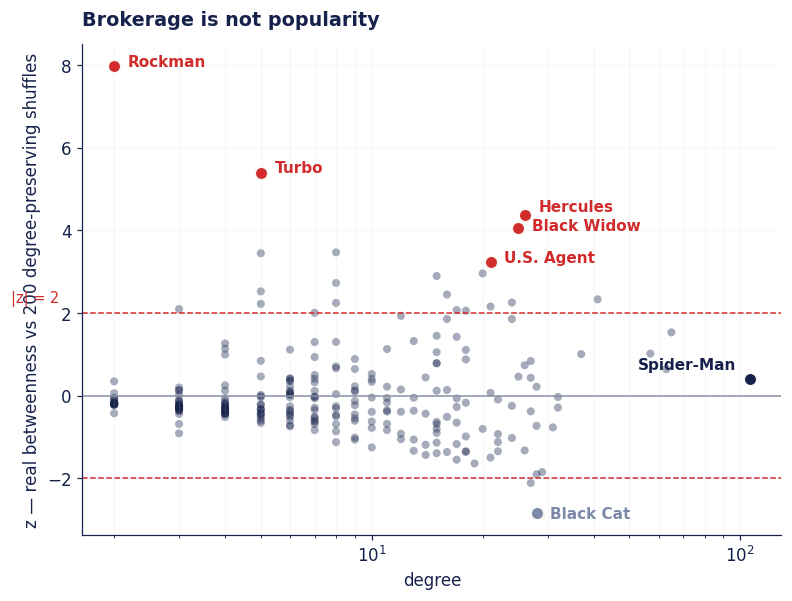

In [17]:
zmap_clean = {order[i]: zb[i] for i in range(len(order))}

fig, ax = plt.subplots(figsize=(8.2, 5.8))
vs = [v for v in GC if not np.isnan(zmap_clean[v])]
ax.scatter([deg[v] for v in vs], [zmap_clean[v] for v in vs],
           s=28, color=marvel.INK, alpha=.38, edgecolors="none")
ax.axhline(0, color=marvel.MUTED, lw=1)
for y in (2, -2):
    ax.axhline(y, color=marvel.RED, ls="--", lw=1)
ax.text(1.05, 2.25, "|z| = 2", color=marvel.RED, fontsize=9.5)
for who, dx, dy in [("Rockman", 9, 0), ("Turbo", 9, 0), ("Hercules", 9, 2),
                    ("Black Widow", 9, -2), ("U.S. Agent", 9, 0),
                    ("Black Cat", 9, -4), ("Spider-Man", -9, 6)]:
    v = next((x for x in GC if short(x) == who), None)
    if v is None or np.isnan(zmap_clean[v]):
        continue
    col = marvel.RED if zmap_clean[v] > 2 else (GREY if zmap_clean[v] < -2 else marvel.INK)
    ax.scatter([deg[v]], [zmap_clean[v]], s=70, color=col, zorder=5,
               edgecolors=marvel.CARD, linewidths=1.2)
    ax.annotate(who, (deg[v], zmap_clean[v]), textcoords="offset points", xytext=(dx, dy),
                fontsize=10, color=col, fontweight="bold", ha="left" if dx > 0 else "right")
ax.set_xscale("log")
ax.set_xlabel("degree")
ax.set_ylabel("z — real betweenness vs 200 degree-preserving shuffles")
ax.set_title("Brokerage is not popularity", loc="left", fontsize=12.5, fontweight="bold", pad=12)
ax.grid(alpha=.15, color=marvel.RULE, which="both")
marvel.save(fig, 3, "broker_z")
plt.show()

wrote weeks/week3/figures/attack.svg


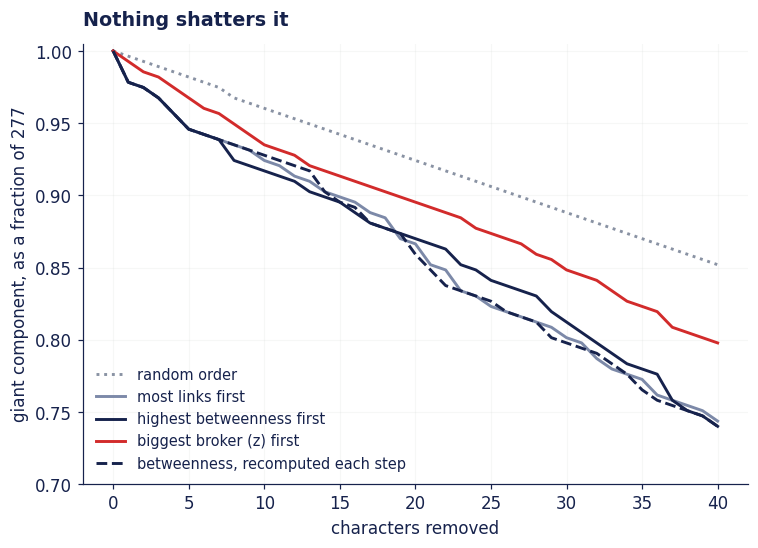

In [18]:
fig, ax = plt.subplots(figsize=(7.8, 5.2))
style = {"random order": (marvel.MUTED, ":"), "most links first": (GREY, "-"),
         "highest betweenness first": (marvel.INK, "-"),
         "biggest broker (z) first": (marvel.RED, "-"),
         "betweenness, recomputed each step": (marvel.INK, "--")}
for k, c in curves.items():
    col, ls = style[k]
    ax.plot(range(len(c)), c, ls, color=col, lw=1.9, label=k)
ax.set_ylim(.7, 1.005)
ax.set_xlabel("characters removed")
ax.set_ylabel("giant component, as a fraction of 277")
ax.set_title("Nothing shatters it", loc="left", fontsize=12.5, fontweight="bold", pad=12)
ax.legend(frameon=False, fontsize=9.5, loc="lower left")
ax.grid(alpha=.15, color=marvel.RULE)
marvel.save(fig, 3, "attack")
plt.show()

### Betweenness against degree

wrote weeks/week3/figures/betweenness_degree.svg


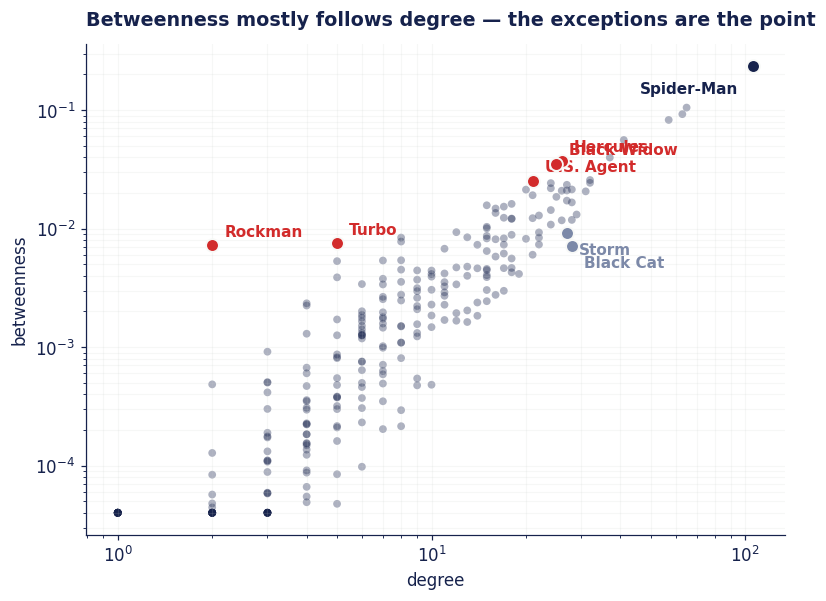

In [19]:
fig, ax = plt.subplots(figsize=(8.2, 5.8))
ax.scatter([deg[v] for v in GC], [max(bet[v], 4e-5) for v in GC],
           s=26, color=marvel.INK, alpha=.35, edgecolors="none")
for lst, col, dy in [(["Rockman", "Turbo", "Hercules", "Black Widow", "U.S. Agent"], marvel.RED, 6),
                     (["Black Cat", "Storm"], GREY, -14)]:
    for who in lst:
        v = next((x for x in GC if short(x) == who), None)
        if v is None:
            continue
        ax.scatter([deg[v]], [bet[v]], s=70, color=col, zorder=5,
                   edgecolors=marvel.CARD, linewidths=1.2)
        ax.annotate(who, (deg[v], bet[v]), textcoords="offset points", xytext=(8, dy),
                    fontsize=10, color=col, fontweight="bold")
ax.scatter([deg[sm]], [bet[sm]], s=70, color=marvel.INK, zorder=5,
           edgecolors=marvel.CARD, linewidths=1.2)
ax.annotate("Spider-Man", (deg[sm], bet[sm]), textcoords="offset points", xytext=(-10, -18),
            fontsize=10, color=marvel.INK, fontweight="bold", ha="right")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("degree"); ax.set_ylabel("betweenness")
ax.set_title("Betweenness mostly follows degree — the exceptions are the point",
             loc="left", fontsize=12.5, fontweight="bold", pad=12)
ax.grid(alpha=.15, color=marvel.RULE, which="both")
marvel.save(fig, 3, "betweenness_degree")
plt.show()

### Rockman's corner of the network

wrote weeks/week3/figures/rockman.svg


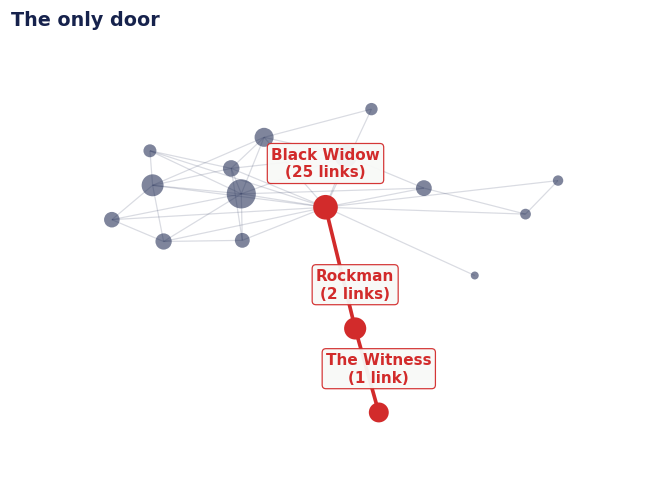

In [20]:
rock_nbrs = set(GC[rock])
keep = {rock} | rock_nbrs
for w in rock_nbrs:
    keep |= set(list(GC[w])[:14])
sub = GC.subgraph(keep)
pos = nx.spring_layout(sub, seed=11, k=.55, iterations=500)
bw = next(v for v in GC if short(v) == "Black Widow")
spine = [(wit, rock), (rock, bw)]

fig, ax = plt.subplots(figsize=(7.6, 5.2))
nx.draw_networkx_edges(sub, pos, ax=ax, edge_color=marvel.INK, alpha=.16, width=.8)
nx.draw_networkx_edges(sub, pos, edgelist=spine, ax=ax, edge_color=marvel.RED, width=2.4)
nx.draw_networkx_nodes(sub, pos, ax=ax, node_size=[24 + 3.2*deg[v] for v in sub],
                       node_color=marvel.INK, alpha=.55, linewidths=0)
nx.draw_networkx_nodes(sub, pos, nodelist=[wit, rock, bw], ax=ax,
                       node_size=[170, 210, 260], node_color=marvel.RED, linewidths=0)
for v, lab in zip([wit, rock, bw],
                  ["The Witness\n(1 link)", "Rockman\n(2 links)", "Black Widow\n(25 links)"]):
    ax.annotate(lab, pos[v], textcoords="offset points", xytext=(0, 20), fontsize=10,
                color=marvel.RED, fontweight="bold", ha="center",
                bbox=dict(boxstyle="round,pad=.25", fc=marvel.CARD, ec=marvel.RED,
                          lw=.8, alpha=.95))
ax.axis("off"); ax.margins(.16)
ax.set_title("The only door", loc="left", fontsize=12.5, fontweight="bold", pad=10)
marvel.save(fig, 3, "rockman")
plt.show()

### PageRank against in-degree

wrote weeks/week3/figures/pagerank.svg


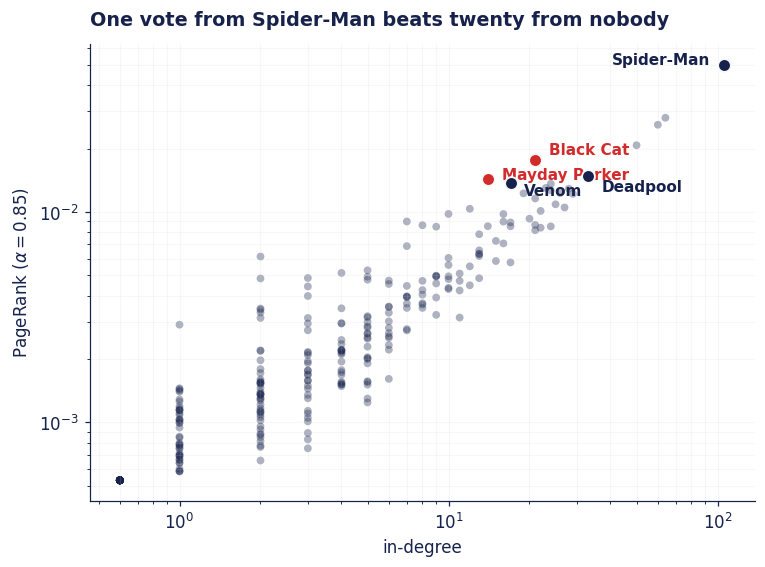

In [21]:
fig, ax = plt.subplots(figsize=(7.8, 5.4))
ax.scatter([max(ind[v], .6) for v in G], [pr[v] for v in G],
           s=26, color=marvel.INK, alpha=.35, edgecolors="none")
for who, dx, dy in [("Black Cat", 9, 4), ("Mayday Parker", 9, 0), ("Venom", 9, -8),
                    ("Spider-Man", -9, 0), ("Deadpool", 9, -10)]:
    v = next((x for x in G if short(x) == who), None)
    if v is None:
        continue
    col = marvel.RED if who in ("Black Cat", "Mayday Parker") else marvel.INK
    ax.scatter([max(ind[v], .6)], [pr[v]], s=70, color=col, zorder=5,
               edgecolors=marvel.CARD, linewidths=1.2)
    ax.annotate(who, (max(ind[v], .6), pr[v]), textcoords="offset points", xytext=(dx, dy),
                fontsize=10, color=col, fontweight="bold", ha="left" if dx > 0 else "right")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("in-degree"); ax.set_ylabel("PageRank ($\\alpha = 0.85$)")
ax.set_title("One vote from Spider-Man beats twenty from nobody", loc="left",
             fontsize=12.5, fontweight="bold", pad=12)
ax.grid(alpha=.15, color=marvel.RULE, which="both")
marvel.save(fig, 3, "pagerank")
plt.show()

### The mixing curve

wrote weeks/week3/figures/knn.svg


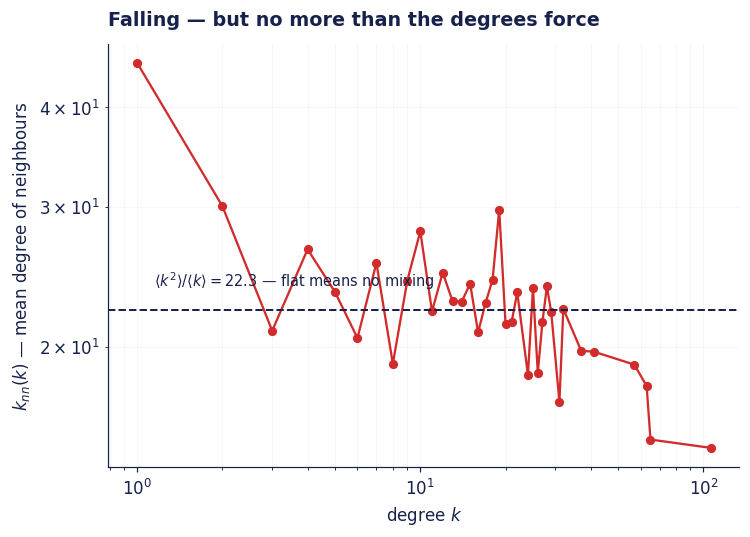

In [22]:
ks = sorted(by_k)
fig, ax = plt.subplots(figsize=(7.4, 5.0))
ax.loglog(ks, [np.mean(by_k[k]) for k in ks], "o-", color=marvel.RED, ms=5, lw=1.5)
flat = (kk**2).mean() / kk.mean()
ax.axhline(flat, color=marvel.INK, ls="--", lw=1.3)
ax.text(1.15, flat*1.07,
        r"$\langle k^2\rangle/\langle k\rangle = %.1f$ — flat means no mixing" % flat,
        color=marvel.INK, fontsize=9.5)
ax.set_xlabel("degree $k$")
ax.set_ylabel(r"$k_{nn}(k)$ — mean degree of neighbours")
ax.set_title("Falling — but no more than the degrees force", loc="left",
             fontsize=12.5, fontweight="bold", pad=12)
ax.grid(alpha=.15, color=marvel.RULE, which="both")
marvel.save(fig, 3, "knn")
plt.show()